In [113]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import os

plt.rcParams['figure.dpi'] = 300

In [117]:
# Define some paths
root = '.'
PATH_TO_DOCKING_RESULTS = os.path.join(root, "..", "processed", "unidock_docking", 'docking_results')

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

In [119]:
pocket_detection_data.sort_values('Pocket score')

,Uniprot AC,File name,Prediction type,Full path,Pocket number,Pocket score,Pocket probability,Pocket centroid coordinate (x y z),Pocket residues (chain_resn),B-factors
182,P9WFV5,chai1_P9WFV5_model_1.pdb,chai1,processed/aligned_relaxed_structures/P9WFV5/ch...,2,1.09,0.007,6.76 13.6009 8.3609,A_115 A_116 A_117 A_126 A_70 A_82,96.48 88.02 82.14 86.75 93.66 96.06
88,P9WFT7,alphafold3_P9WFT7_model_2.pdb,alphafold3,processed/aligned_relaxed_structures/P9WFT7/al...,2,1.20,0.009,5.2024 19.2165 0.7308,A_160 A_162 A_170 A_254 A_275 A_276 A_277,96.52 97.51 89.58 96.19 88.84 97.8 93.18
140,P9WFU9,swissmodel_P9WFU9_model_0.pdb,swissmodel,processed/aligned_relaxed_structures/P9WFU9/sw...,2,1.26,0.011,-17.8269 10.9128 40.3659,A_124 A_125 A_126 A_134 A_55 A_77 A_79 A_93 A_...,0.93 0.92 0.91 0.95 0.88 0.91 0.93 0.94 0.93 0.89
56,P9WFT3,alphafold3_P9WFT3_model_3.pdb,alphafold3,processed/aligned_relaxed_structures/P9WFT3/al...,2,1.26,0.011,-4.7519 -14.951 -5.4106,A_18 A_19 A_209 A_212 A_214 A_217 A_221,80.84 86.39 73.17 78.5 86.63 87.13 85.08
191,P9WFV7,chai1_P9WFV7_model_3.pdb,chai1,processed/aligned_relaxed_structures/P9WFV7/ch...,2,1.32,0.012,11.9012 5.6409 -12.344,A_13 A_14 A_17 A_205 A_24 A_27 A_36,86.97 68.29 77.17 87.25 91.42 78.26 88.39
...,...,...,...,...,...,...,...,...,...,...
129,P9WFU5,alphafold2_P9WFU5_model_0.pdb,alphafold2,processed/aligned_relaxed_structures/P9WFU5/al...,1,44.14,0.956,-4.7003 12.2629 1.4359,A_10 A_11 A_12 A_128 A_129 A_14 A_15 A_16 A_18...,96.15 93.87 92.01 80.99 81.55 89.02 87.46 89.9...
188,P9WFV7,alphafold3_P9WFV7_model_0.pdb,alphafold3,processed/aligned_relaxed_structures/P9WFV7/al...,1,47.57,0.964,-8.0531 -8.8134 -8.4361,A_102 A_105 A_144 A_164 A_165 A_197 A_199 A_20...,75.04 76.29 78.23 97.64 94.84 88.68 82.68 93.5...
134,P9WFU9,alphafold2_P9WFU9_model_0.pdb,alphafold2,processed/aligned_relaxed_structures/P9WFU9/al...,1,48.49,0.965,6.9492 -0.428 -15.1373,A_211 A_212 A_213 A_233 A_235 A_257 A_259 A_26...,94.07 93.66 91.41 98.24 98.65 97.25 89.6 84.57...
216,P9WFW1,swissmodel_P9WFW1_model_1.pdb,swissmodel,processed/aligned_relaxed_structures/P9WFW1/sw...,1,50.75,0.968,2.2762 7.7854 -9.8577,B_101 B_105 B_206 B_207 B_208 B_210 B_229 B_23...,0.79 0.79 0.74 0.68 0.84 0.82 0.86 0.79 0.78 0...


In [116]:
DOCKING_RESULTS = {}

# For each pocket
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS))):

    try:

        # Get scores
        scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS, pocket, 'report.csv'))

        # Save results
        DOCKING_RESULTS[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

    except:
        pass

100%|██████████| 105/105 [00:05<00:00, 20.72it/s]


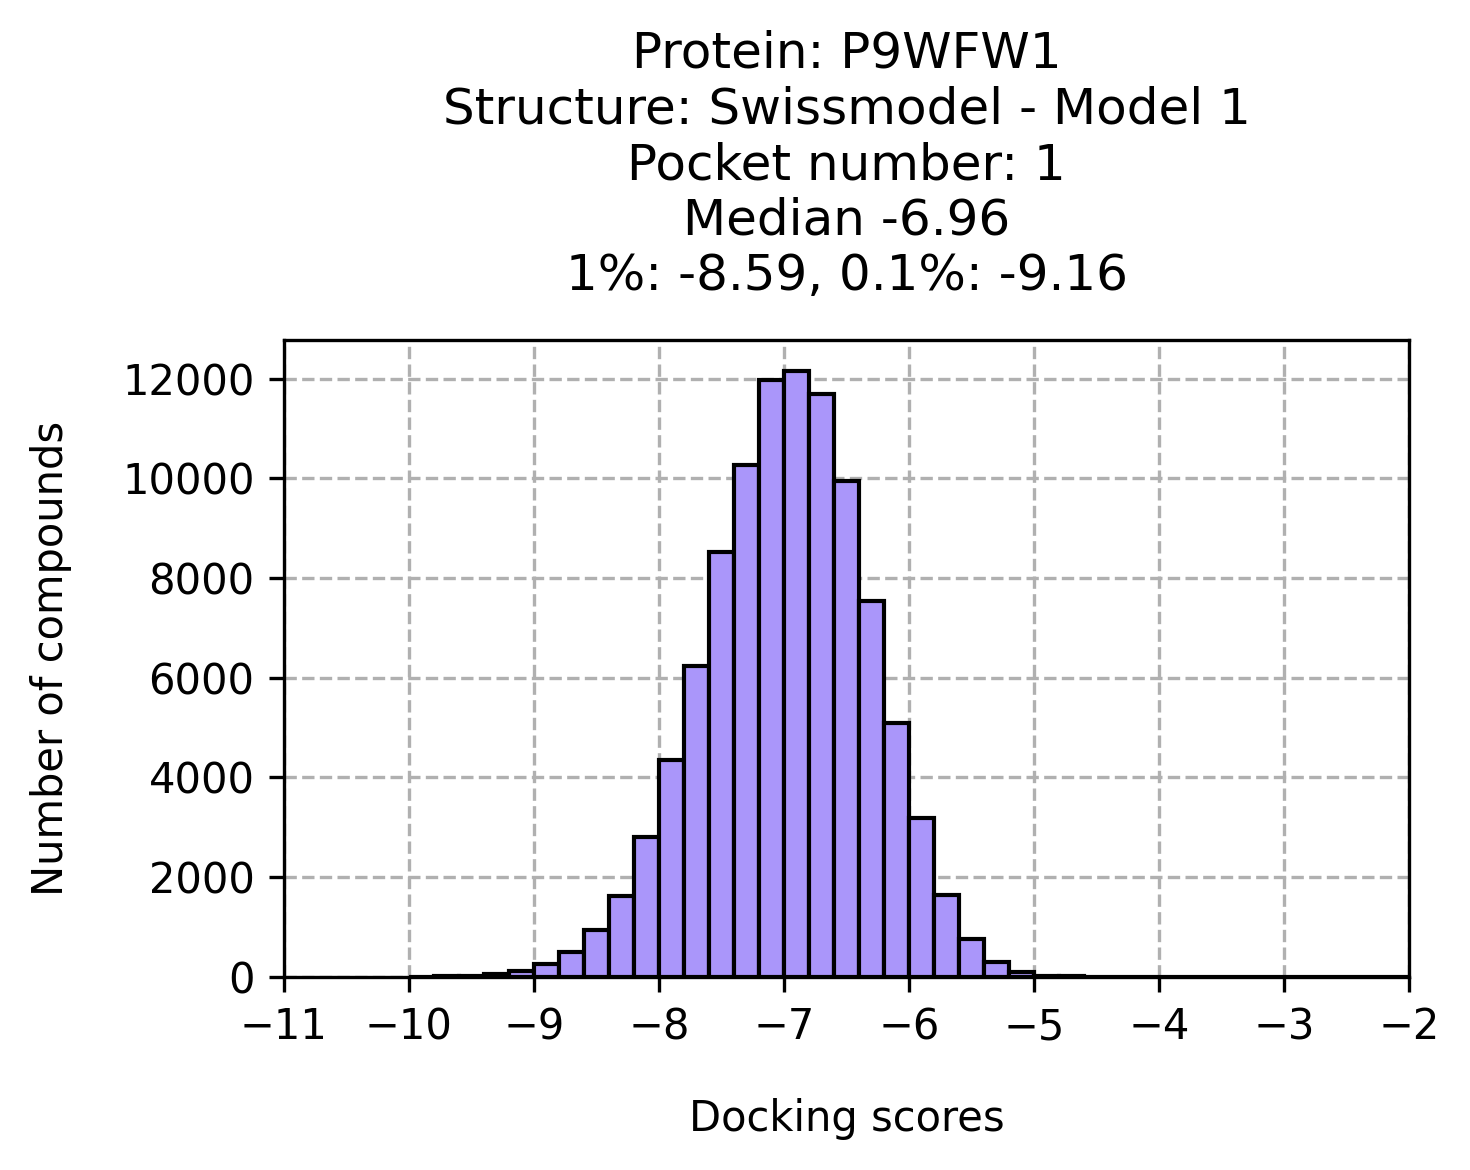

In [120]:
pocket = 'swissmodel_P9WFW1_model_1_pocket_1'
y = list(DOCKING_RESULTS[pocket].values())
bins = [i for i in np.arange(-10, 1, 0.2)]

p = f"Protein: {pocket.split('_')[1]}\nStructure: {pocket.split('_')[0].capitalize()} - Model {pocket.split('_')[3]}\nPocket number: {pocket.split('_')[-1]}"
title = f"{p}\nMedian {round(np.median(y), 2)}\n1%: {round(np.percentile(y, 1), 2)}, 0.1%: {round(np.percentile(y, 0.1), 2)}"

plt.figure(figsize=(5, 4))
plt.hist(y, bins=bins, zorder=2, edgecolor='k', color="#AA96FA")
plt.grid(linestyle='--', zorder=-2)
plt.xlim([-11, -2])
plt.xlabel("Docking scores", labelpad=12)
plt.ylabel("Number of compounds", labelpad=12)
plt.title(title, pad=12)
plt.tight_layout()
plt.show()

In [121]:
pocket

'swissmodel_P9WFW1_model_1_pocket_1'

In [123]:
[[i, DOCKING_RESULTS[pocket][i]] for i in DOCKING_RESULTS[pocket] if DOCKING_RESULTS[pocket][i] < -10]

[['Z1591057304', -10.19],
 ['Z1883396970', -10.249],
 ['Z431759748', -10.32],
 ['Z4484838485', -10.041]]

In [128]:
[[i, DOCKING_RESULTS[pocket][i]] for i in DOCKING_RESULTS[pocket] if DOCKING_RESULTS[pocket][i] > -4.8]

[['Z1400391952', -4.791],
 ['Z1791008657', -4.672],
 ['Z1834175205', -4.764],
 ['Z1855788771', -4.684],
 ['Z1958246521', -4.782],
 ['Z2058774759', -4.703],
 ['Z2097614857', -4.79],
 ['Z2110951190', -4.791],
 ['Z2185756182', -4.644],
 ['Z2334662645', -4.786],
 ['Z2379496879', -4.786],
 ['Z2672854668', -4.676],
 ['Z2715493274', -4.708],
 ['Z382787640', -4.756]]